**Generating Dataset Based on Kaggle Data**

In [1]:
import pandas as pd
import numpy as np
import random

# Reproducibility
np.random.seed(42)
random.seed(42)

# Sample names
first_names = [
    "John","Sarah","Alex","Michael","Emma","Olivia","Daniel","Sophia",
    "James","Isabella","Liam","Ava","Noah","Mia","Ethan","Charlotte",
    "Lucas","Amelia","Benjamin","Harper","Elijah","Evelyn","Henry",
    "Abigail","Alexander","Emily","Matthew","Ella","David","Scarlett"
]

genders = ["Male", "Female"]
parent_support = ["Low", "Medium", "High"]

data = []

for i in range(1, 1001):

    name = random.choice(first_names)
    gender = random.choice(genders)

    attendance = np.random.randint(60, 101)        # 60-100%
    study_hours = np.random.randint(5, 36)         # 5-35 hrs/week
    previous_grade = np.random.randint(50, 96)     # 50-95
    extracurricular = np.random.randint(0, 4)      # 0-3
    parental = random.choice(parent_support)

    # Bonuses
    parental_bonus = {
        "Low": 0,
        "Medium": 2,
        "High": 5
    }[parental]

    extra_bonus = extracurricular * 1.5

    # Final Grade Formula
    final_grade = (
        0.35 * previous_grade +
        0.30 * attendance +
        0.25 * study_hours +
        parental_bonus +
        extra_bonus +
        np.random.normal(0, 3)
    )

    final_grade = round(max(40, min(100, final_grade)))

    data.append([
        i,
        name,
        gender,
        attendance,
        study_hours,
        previous_grade,
        extracurricular,
        parental,
        final_grade
    ])

# Create DataFrame
df = pd.DataFrame(data, columns=[
    "StudentID",
    "Name",
    "Gender",
    "AttendanceRate",
    "StudyHoursPerWeek",
    "PreviousGrade",
    "ExtracurricularActivities",
    "ParentalSupport",
    "FinalGrade"
])

# Save CSV
df.to_csv("student_performance_1000.csv", index=False)

print(df.head())
print("\nDataset Shape:", df.shape)

   StudentID     Name  Gender  AttendanceRate  StudyHoursPerWeek  \
0          1   Elijah    Male              98                 24   
1          2  Abigail  Female              98                 30   
2          3   Sophia    Male              70                 15   
3          4  Michael    Male              81                 25   
4          5      Mia    Male              89                 10   

   PreviousGrade  ExtracurricularActivities ParentalSupport  FinalGrade  
0             78                          2             Low          68  
1             68                          2             Low          68  
2             73                          0            High          60  
3             51                          3            High          60  
4             51                          3             Low          52  

Dataset Shape: (1000, 9)


**Installing Required Libraries**

In [2]:
pip install pandas numpy scikit-learn matplotlib seaborn

**Loading Dataset**

In [3]:
import pandas as pd

df = pd.read_csv("student_performance_1000.csv")

print(df.head())
print(df.info())

   StudentID     Name  Gender  AttendanceRate  StudyHoursPerWeek  \
0          1   Elijah    Male              98                 24   
1          2  Abigail  Female              98                 30   
2          3   Sophia    Male              70                 15   
3          4  Michael    Male              81                 25   
4          5      Mia    Male              89                 10   

   PreviousGrade  ExtracurricularActivities ParentalSupport  FinalGrade  
0             78                          2             Low          68  
1             68                          2             Low          68  
2             73                          0            High          60  
3             51                          3            High          60  
4             51                          3             Low          52  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                     Non-Null C

**Converting Features**

In [4]:
from sklearn.preprocessing import LabelEncoder

le_gender = LabelEncoder()
le_parent = LabelEncoder()

df["Gender"] = le_gender.fit_transform(df["Gender"])
df["ParentalSupport"] = le_parent.fit_transform(df["ParentalSupport"])

**Selecting Features**

In [5]:
X = df[
    [
        "Gender",
        "AttendanceRate",
        "StudyHoursPerWeek",
        "PreviousGrade",
        "ExtracurricularActivities",
        "ParentalSupport"
    ]
]

In [6]:
y = df["FinalGrade"]

**Split Dataset**

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**Train Random Forest**

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**Evaluate Model**

In [10]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.ensemble import RandomForestRegressor

# Initialize and train a RandomForestRegressor model
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE:", round(mae,2))
print("RMSE:", round(rmse,2))
print("R² Score:", round(r2,2))

MAE: 2.59
RMSE: 3.29
R² Score: 0.79


**Feature Importance**

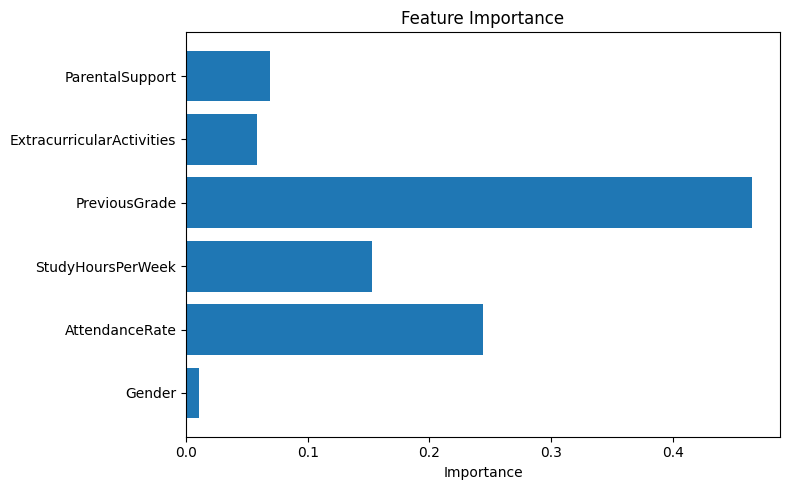

In [11]:
import matplotlib.pyplot as plt

importance = model.feature_importances_

features = X.columns

plt.figure(figsize=(8,5))
plt.barh(features, importance)
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

**Save Model**

In [12]:
import pickle

with open("student_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model Saved!")

Model Saved!


**Test Prediction**

In [13]:
sample = [[
    1,      # Gender
    90,     # Attendance
    20,     # Study Hours
    85,     # Previous Grade
    2,      # Extracurricular
    2       # High Parental Support
]]

prediction = model.predict(sample)

print("Predicted Final Grade:", round(prediction[0],2))

Predicted Final Grade: 67.75


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
